In [1]:
import squidpy as sq
import anndata
import mudata as md
import muon as mu
import scanpy as sc
import torch
import matplotlib.pyplot as plt
from omics_topic.models.amortizedLDA import MultimodalAmortizedLDA

import warnings
warnings.filterwarnings('ignore', message='.*was not registered in the param store.*')
warnings.filterwarnings('ignore', message='.*Found plate statements in guide but not model.*')

torch.set_float32_matmul_precision('medium')

/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autono

### Spatial Transcriptomics example

In [2]:
adata = sq.datasets.visium_hne_adata()  # H&E-stained Visium section

In [3]:
adata

AnnData object with n_obs × n_vars = 2688 × 18078
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'leiden', 'cluster'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cluster_colors', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'rank_genes_groups', 'spatial', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [4]:
#we need the raw counts
adata.X = adata.raw.X

In [5]:
#This needs to be run to setup the model. Pass a adata (or mudata), and pass the key of the obsp containing
#the connectivity graph

#adata.uns.pop("_spatial_graph", None)
#adata.uns.pop("_spatial_graphs", None)
#MultimodalAmortizedLDA.setup_anndata(adata, spatial_key='connectivities')

In [7]:
adata

AnnData object with n_obs × n_vars = 2688 × 18078
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'leiden', 'cluster'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cluster_colors', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'rank_genes_groups', 'spatial', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [8]:
model = MultimodalAmortizedLDA.from_data(
    adata,
    modalities=['rna'],
    spatial_keys='connectivities',
    #specify the likelihoods (here 1 modality only). Can be multinomial or gamma_poisson
    likelihoods=["gamma_poisson"],
    cell_topic_prior=1000,
    n_topics=10,
    n_hidden=64, #hidden layer size in the encoder
)

#These flags should all be true and show that the model is supporting the spatial graph
print("spatial flag:", model.spatial)                             
print("use_gcn:", model.module.guide.use_gcn)                     
print("gcn encoders:", model.module.guide.gcn_encoders is not None)


spatial flag: True
use_gcn: True
gcn encoders: True


In [7]:
adata

AnnData object with n_obs × n_vars = 2688 × 18078
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'leiden', 'cluster'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cluster_colors', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'rank_genes_groups', 'spatial', 'umap', '_spatial_graph', '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [9]:
device = next(model.module.parameters()).device  # Get the device (cuda:0 or cpu)

# Prepare full data
x_full = torch.FloatTensor(adata.X.toarray()).to(device)

# Initialize transductive learning
model.module.set_full_graph_data(x_full)

In [10]:
model._training_plan_cls


omics_topic.utils.training_plan.MultimodalLDAPyroTrainingPlan

In [11]:
# model.train() is inherited from PyroSVIMixin from scvi-tools. Here are all the options: 
# https://github.com/scverse/scvi-tools/blob/main/src/scvi/model/base/_pyromixin.py#L95

model.train(
    max_epochs=100,
    batch_size=128,  
    train_size=0.8,          
    validation_size=0.2,      
    log_every_n_steps=1,     
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=111` in the `DataLoader` to improve performance.
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=111` in the `DataLoader` to improve performance.


Epoch 100/100: 100%|██████████| 100/100 [00:46<00:00,  2.18it/s, v_num=1, elbo_val=1.19e+7, elbo_train=4.73e+7]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 100/100: 100%|██████████| 100/100 [00:46<00:00,  2.17it/s, v_num=1, elbo_val=1.19e+7, elbo_train=4.73e+7]


Text(0, 0.5, 'ELBO')

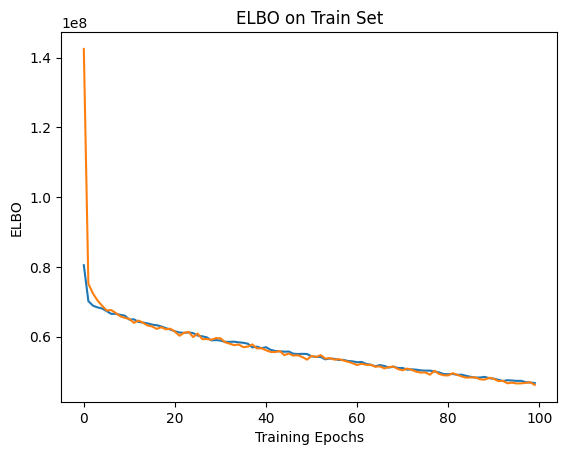

In [11]:
plt.plot(model.history['elbo_train'])
plt.plot(model.history['elbo_val']*4)
plt.title('ELBO on Train Set')
plt.xlabel('Training Epochs')
plt.ylabel('ELBO')

In [12]:
import numpy as np
import pandas as pd
import scanpy as sc

# 1) Topic proportions per cell, visualized on UMAP
theta = model.get_latent_representation(adata, batch_size=adata.n_obs)  # full batch
adata.obsm["X_topic"] = theta.values
adata.obs["top_topic"] = theta.idxmax(axis=1)

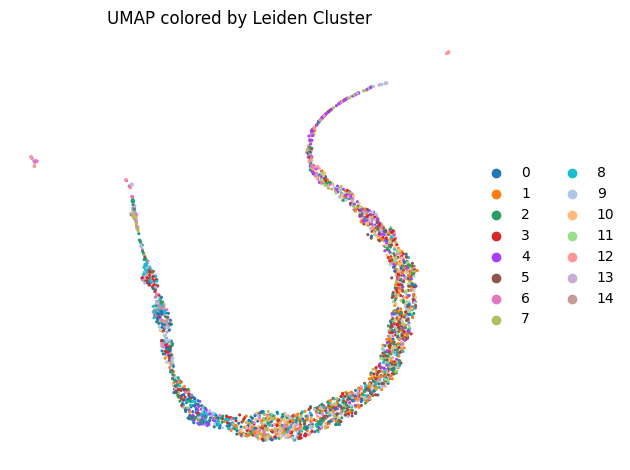

In [13]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

# 1) Get topic proportions per cell
theta = model.get_latent_representation(adata, batch_size=adata.n_obs)  # full batch
adata.obsm["X_topic"] = theta.values - 1/theta.values.shape[1]

# 2) Compute UMAP on topic space
sc.pp.neighbors(adata, use_rep="X_topic", n_neighbors=15, metric="cosine")
sc.tl.umap(adata, min_dist=0.3)

# 3) Get dominant topic per cell
adata.obs["dominant_topic"] = theta.idxmax(axis=1).values

# 4) IMPORTANT: Clean up any old color information to avoid conflicts
if "dominant_topic_colors" in adata.uns:
    del adata.uns["dominant_topic_colors"]

# 5) Convert to categorical for better plotting
adata.obs["dominant_topic"] = pd.Categorical(adata.obs["dominant_topic"])


# Right: Color by leiden (if available) or any other annotation
if "leiden" in adata.obs.columns:
    sc.pl.umap(
        adata,
        color="leiden",
        frameon=False,
        s=20,
        title="UMAP colored by Leiden Cluster",
        show=False,
        legend_loc="right margin"
    )
else:
    # Compute leiden if not present
    sc.tl.leiden(adata, resolution=0.5)
    sc.pl.umap(
        adata,
        color="leiden",
        frameon=False,
        s=20,
        title="UMAP colored by Leiden Cluster",
        show=False,
        legend_loc="right margin"
    )

plt.tight_layout()
plt.show()

/tmp/ipykernel_1536657/4107442915.py:29: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/tmp/ipykernel_1536657/4107442915.py:41: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/tmp/ipykernel_1536657/4107442915.py:41: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/tmp/ipykernel_1536657/4107442915.py:41: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/tmp/ipykernel_1536657/4107442915.py:41: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/tmp/ipykernel_1536657/4107442915.py:41: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/tmp/ipykernel_1536657/4107442915.py:41: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/tmp/ipykernel_1536657/4107442915.py:41: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/tmp/ipykernel_1536657/4107442915.py:41: FutureWarning: Use `squidpy.pl.spatial_

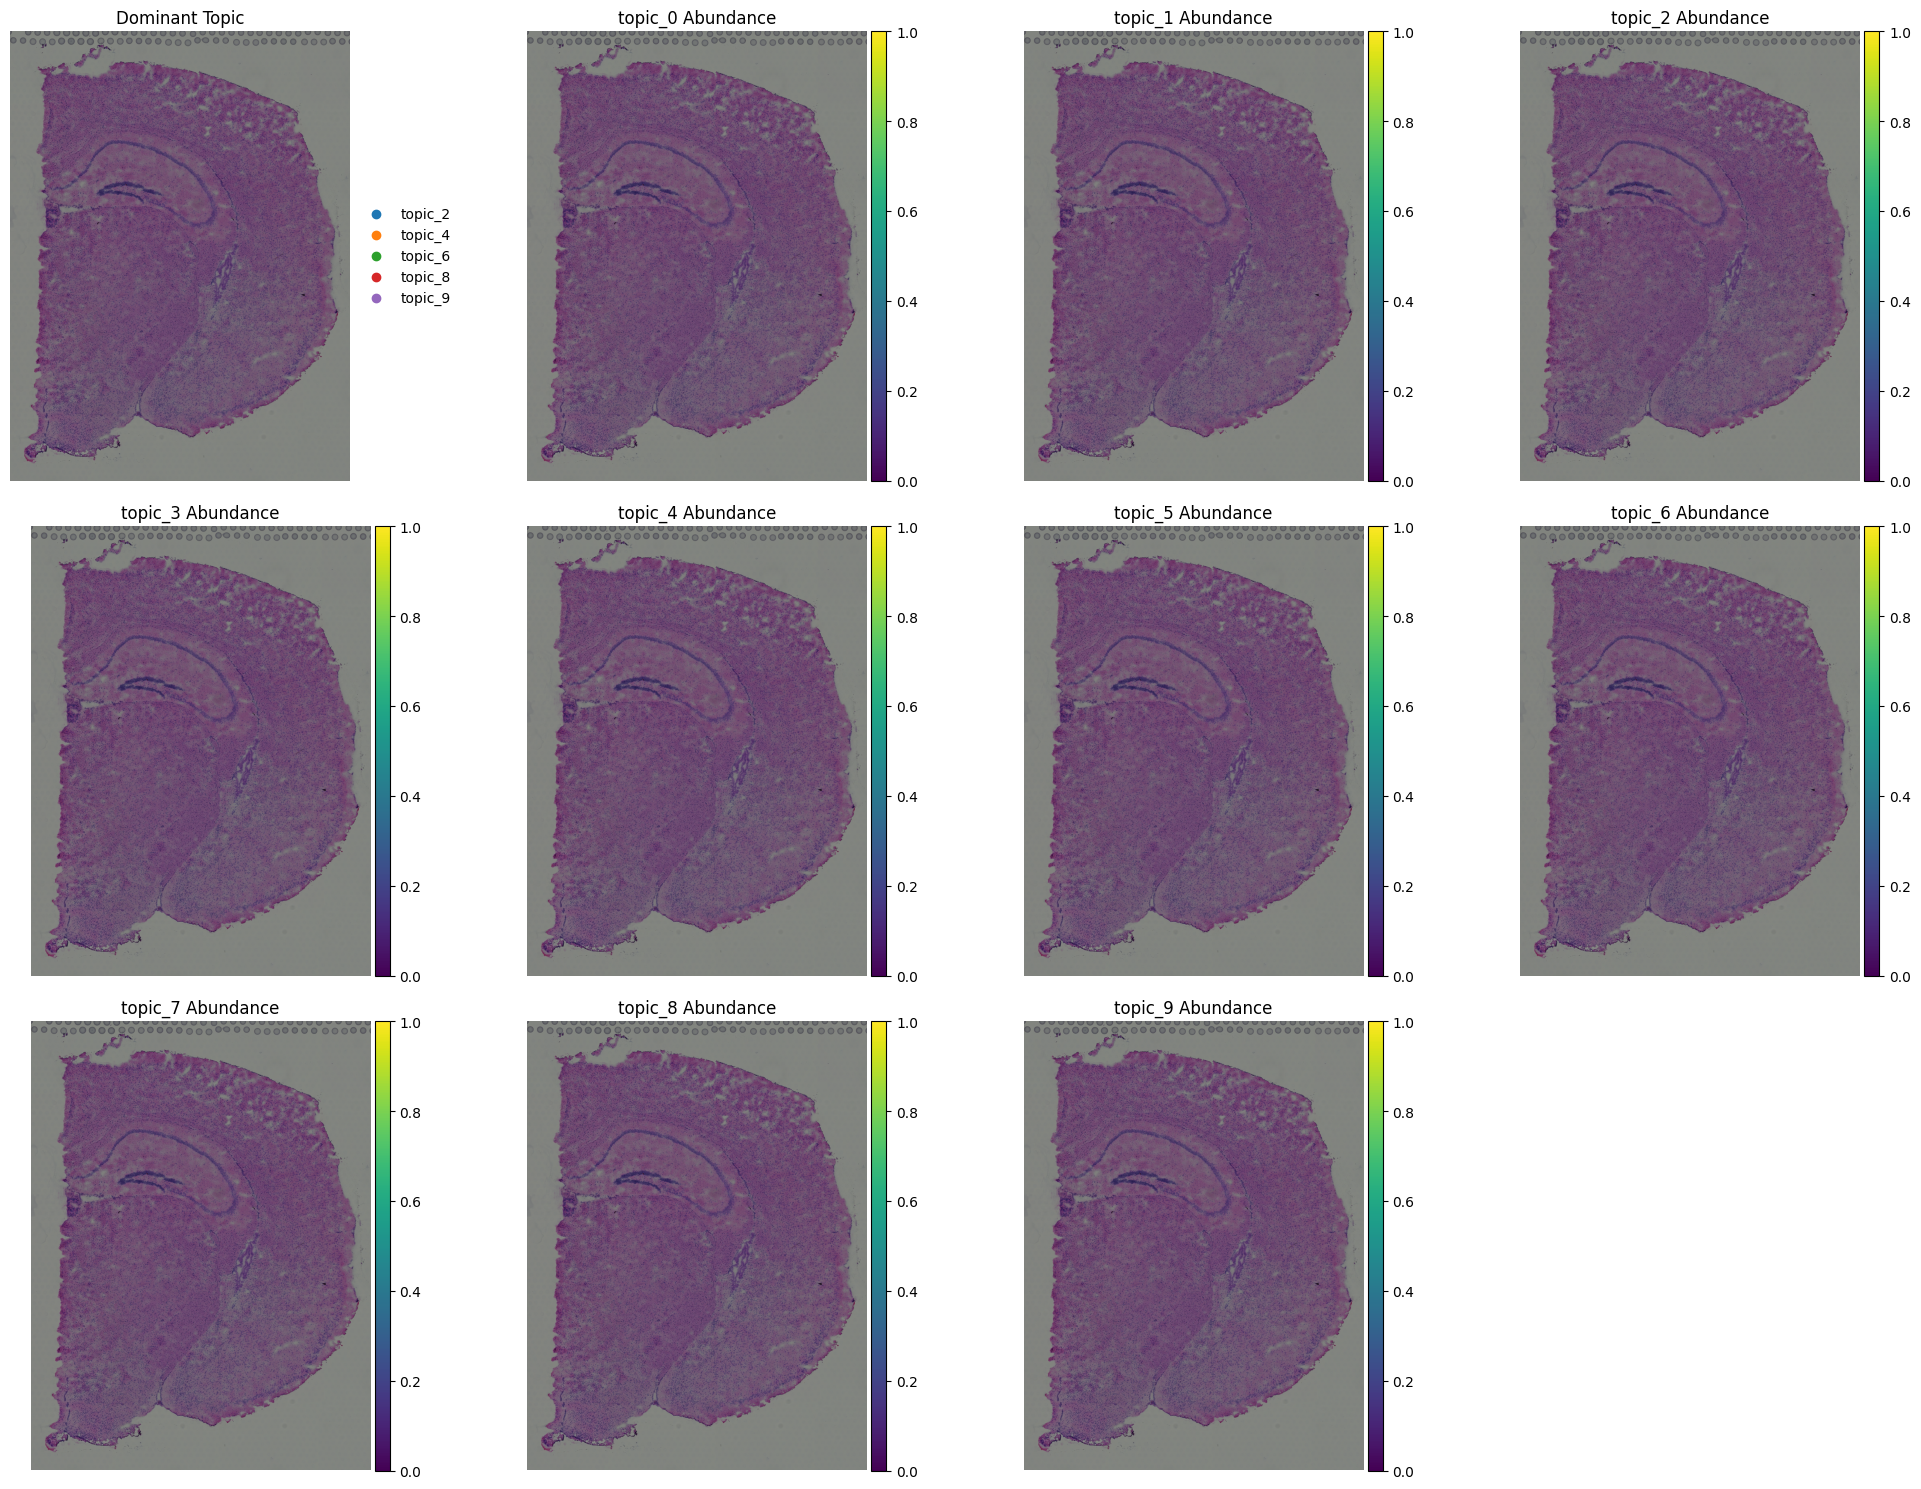

/tmp/ipykernel_1536657/4107442915.py:70: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/tmp/ipykernel_1536657/4107442915.py:70: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/tmp/ipykernel_1536657/4107442915.py:70: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/tmp/ipykernel_1536657/4107442915.py:70: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/tmp/ipykernel_1536657/4107442915.py:70: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/tmp/ipykernel_1536657/4107442915.py:70: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/tmp/ipykernel_1536657/4107442915.py:70: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/tmp/ipykernel_1536657/4107442915.py:70: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/tmp/ipykernel_1536657/4107442915.py:70: FutureWarning: Use `squidpy.pl.spatial_

Saved 10 individual spatial plots


/tmp/ipykernel_1536657/4107442915.py:102: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/tmp/ipykernel_1536657/4107442915.py:102: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/tmp/ipykernel_1536657/4107442915.py:102: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


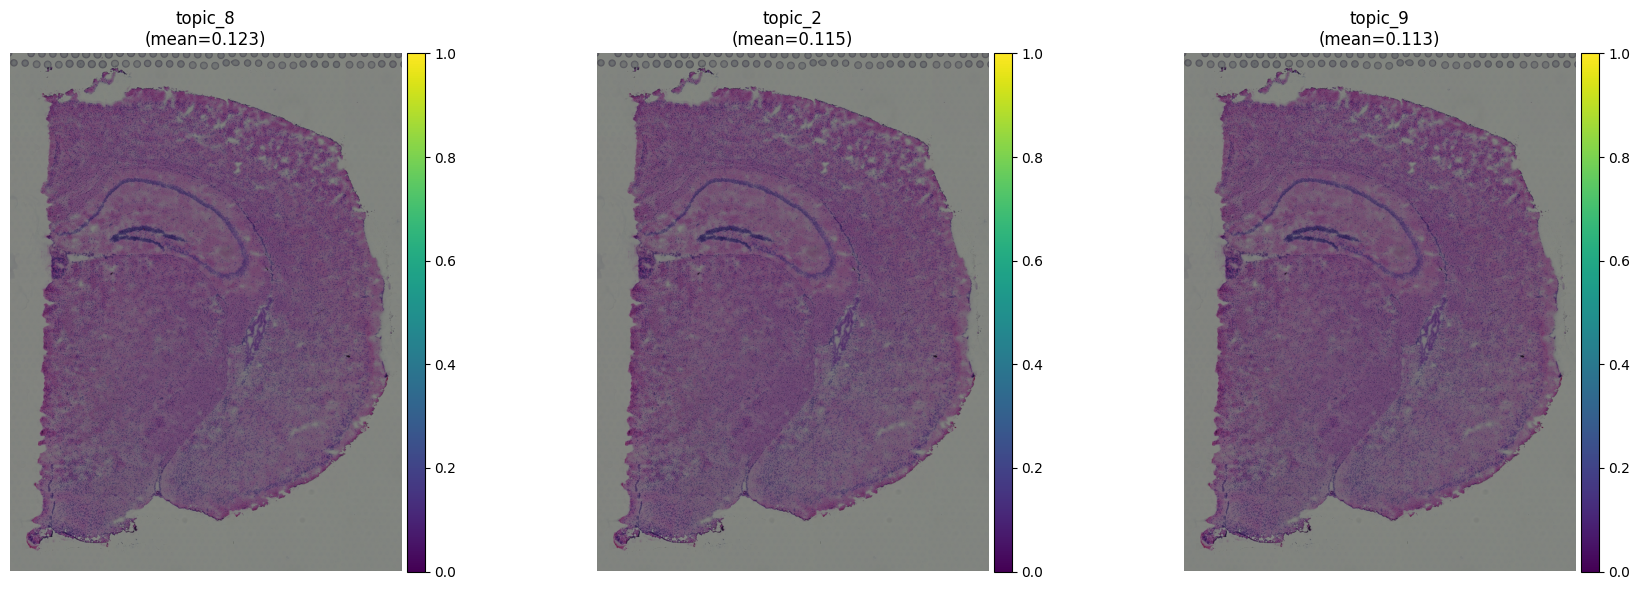

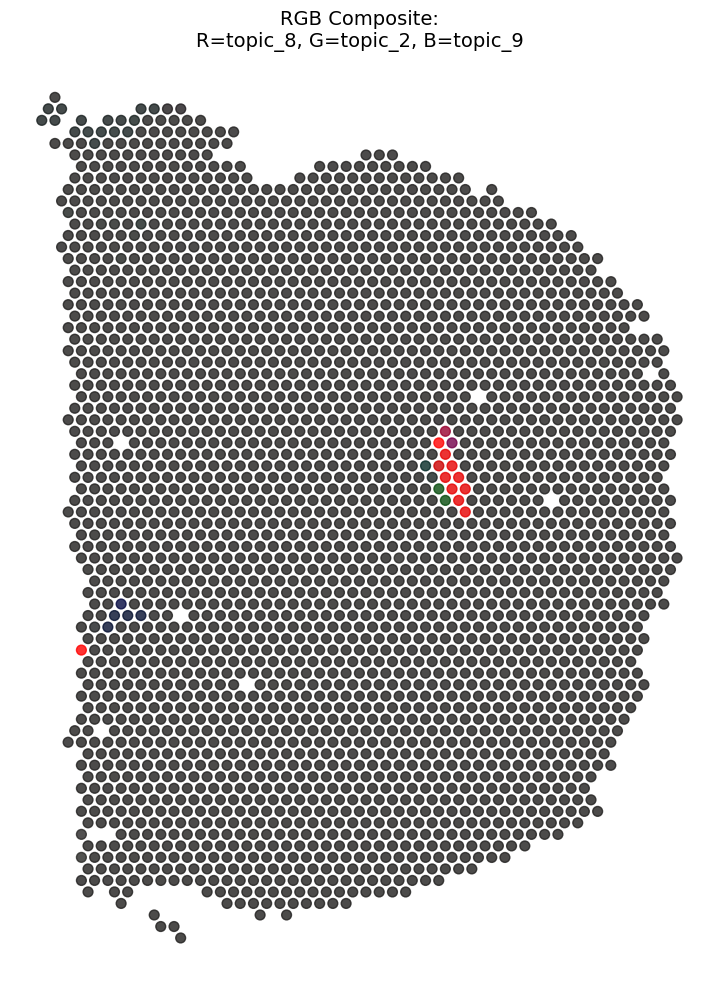

/tmp/ipykernel_1536657/4107442915.py:181: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/tmp/ipykernel_1536657/4107442915.py:192: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


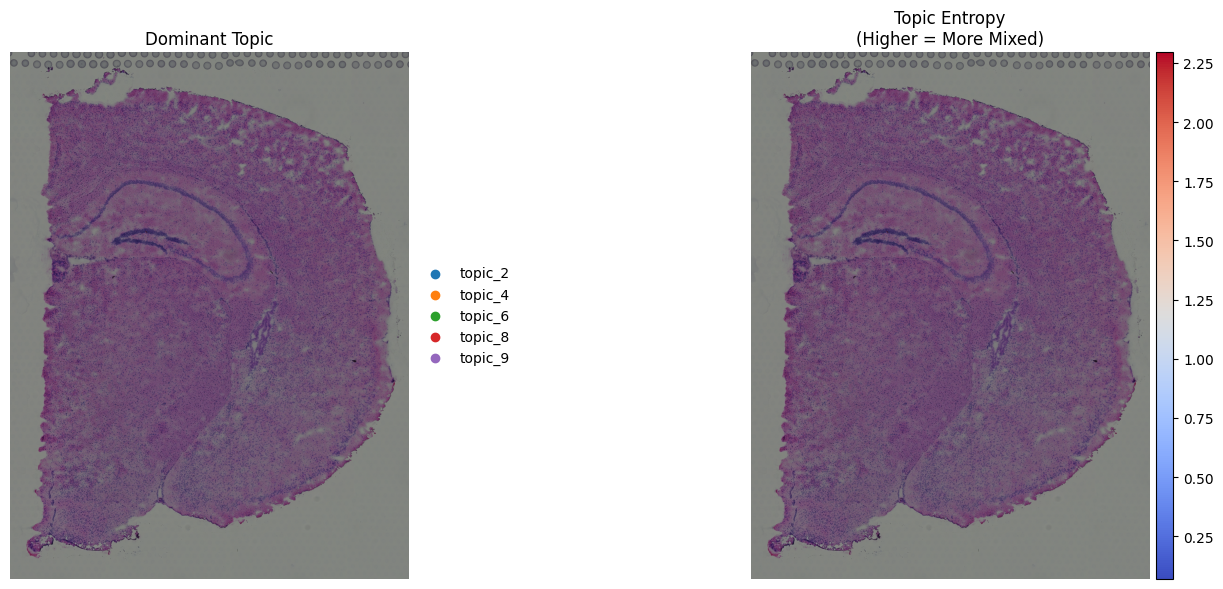


TOPIC ABUNDANCE SUMMARY
          Mean    Std    Min    Max  # Dominant Spots
topic_0  0.080  0.007  0.000  0.089                 0
topic_1  0.084  0.007  0.000  0.187                 0
topic_2  0.115  0.010  0.000  0.294                 5
topic_3  0.099  0.008  0.000  0.101                 0
topic_4  0.104  0.017  0.000  0.463                21
topic_5  0.093  0.008  0.000  0.101                 0
topic_6  0.103  0.010  0.000  0.344                 8
topic_7  0.086  0.005  0.011  0.200                 0
topic_8  0.123  0.051  0.010  0.988              2653
topic_9  0.113  0.009  0.000  0.289                 1


In [16]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

# Get topic distributions
theta = model.get_latent_representation(adata, batch_size=adata.n_obs)
n_topics = theta.shape[1]

# Add topic weights to adata.obs for plotting
for topic in theta.columns:
    adata.obs[topic] = theta[topic].values

# Get dominant topic
adata.obs["dominant_topic"] = theta.idxmax(axis=1).values

# ============================================================================
# Option 1: Grid layout - all topics in one figure
# ============================================================================

n_cols = 4
n_rows = int(np.ceil((n_topics + 1) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows))
axes = axes.flatten()

# Plot dominant topic
sc.pl.spatial(
    adata,
    color="dominant_topic",
    ax=axes[0],
    spot_size=1.5,
    frameon=False,
    title="Dominant Topic",
    show=False
)

# Plot each topic's abundance
for i, topic in enumerate(theta.columns):
    sc.pl.spatial(
        adata,
        color=topic,
        ax=axes[i + 1],
        spot_size=5,
        frameon=False,
        title=f"{topic} Abundance",
        cmap="viridis",
        vmin=0,
        vmax=1,
        show=False
    )

# Remove empty subplots
for j in range(n_topics + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("spatial_topics_grid.png", dpi=150, bbox_inches="tight")
plt.show()


# ============================================================================
# Option 2: Individual high-resolution plots per topic
# ============================================================================

for topic in theta.columns:
    fig, ax = plt.subplots(figsize=(8, 8))
    
    sc.pl.spatial(
        adata,
        color=topic,
        ax=ax,
        spot_size=5,
        frameon=False,
        title=f"{topic} Spatial Distribution",
        cmap="viridis",
        vmin=0,
        vmax=1,
        show=False,
        colorbar_loc="right"
    )
    
    plt.tight_layout()
    plt.savefig(f"spatial_{topic}.png", dpi=150, bbox_inches="tight")
    plt.close()

print(f"Saved {n_topics} individual spatial plots")


# ============================================================================
# Option 3: Compare top 3 topics side-by-side
# ============================================================================

# Find topics with highest average abundance
topic_means = theta.mean(axis=0).sort_values(ascending=False)
top_topics = topic_means.head(3).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, topic in enumerate(top_topics):
    sc.pl.spatial(
        adata,
        color=topic,
        ax=axes[idx],
        spot_size=5,
        frameon=False,
        title=f"{topic}\n(mean={topic_means[topic]:.3f})",
        cmap="viridis",
        vmin=0,
        vmax=1,
        show=False
    )

plt.tight_layout()
plt.savefig("spatial_top3_topics.png", dpi=150, bbox_inches="tight")
plt.show()


# ============================================================================
# Option 4: RGB composite (3 topics as RGB channels)
# ============================================================================

if n_topics >= 3:
    # Select 3 topics (can be top 3 or specific topics of interest)
    rgb_topics = top_topics[:3]
    
    # Normalize each topic to [0, 1]
    rgb_array = np.stack([
        theta[rgb_topics[0]].values,
        theta[rgb_topics[1]].values,
        theta[rgb_topics[2]].values,
    ], axis=-1)
    
    # Normalize to [0, 1] range
    rgb_array = (rgb_array - rgb_array.min()) / (rgb_array.max() - rgb_array.min())
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Get spatial coordinates
    if "spatial" in adata.obsm:
        coords = adata.obsm["spatial"]
    else:
        # Fallback: use obs columns
        coords = adata.obs[["x", "y"]].values
    
    scatter = ax.scatter(
        coords[:, 0],
        coords[:, 1],
        c=rgb_array,
        s=50,
        alpha=0.8
    )
    
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(
        f"RGB Composite:\nR={rgb_topics[0]}, G={rgb_topics[1]}, B={rgb_topics[2]}",
        fontsize=14
    )
    
    plt.tight_layout()
    plt.savefig("spatial_rgb_composite.png", dpi=150, bbox_inches="tight")
    plt.show()


# ============================================================================
# Option 5: Entropy map (how mixed are topics per spot?)
# ============================================================================

from scipy.stats import entropy

# Compute entropy per spot
spot_entropies = entropy(theta.T)  # Higher = more mixed topics
adata.obs["topic_entropy"] = spot_entropies

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Dominant topic
sc.pl.spatial(
    adata,
    color="dominant_topic",
    ax=axes[0],
    spot_size=1.5,
    frameon=False,
    title="Dominant Topic",
    show=False
)

# Right: Entropy (how certain is the topic assignment?)
sc.pl.spatial(
    adata,
    color="topic_entropy",
    ax=axes[1],
    spot_size=1.5,
    frameon=False,
    title="Topic Entropy\n(Higher = More Mixed)",
    cmap="coolwarm",
    show=False,
    colorbar_loc="right"
)

plt.tight_layout()
plt.savefig("spatial_entropy.png", dpi=150, bbox_inches="tight")
plt.show()





# ============================================================================
# Summary statistics
# ============================================================================

print("\n" + "="*70)
print("TOPIC ABUNDANCE SUMMARY")
print("="*70)

summary_df = pd.DataFrame({
    "Mean": theta.mean(),
    "Std": theta.std(),
    "Min": theta.min(),
    "Max": theta.max(),
    "# Dominant Spots": [(theta.idxmax(axis=1) == topic).sum() for topic in theta.columns]
})

print(summary_df.round(3).to_string())



In [17]:
summary_df

,Mean,Std,Min,Max,# Dominant Spots
topic_0,0.080355,0.006640,2.058206e-06,0.088859,0
topic_1,0.084198,0.007090,3.538615e-04,0.187189,0
topic_2,0.115312,0.009939,5.888952e-07,0.294125,5
topic_3,0.099000,0.007853,6.057004e-06,0.100998,0
topic_4,0.104199,0.016513,4.284066e-06,0.463489,21
topic_5,0.092545,0.008189,6.602548e-13,0.101293,0
topic_6,0.102532,0.010414,6.968521e-05,0.343764,8
topic_7,0.086416,0.004906,1.137446e-02,0.200091,0
topic_8,0.122695,0.051495,1.002063e-02,0.987806,2653
topic_9,0.112748,0.009154,1.824452e-06,0.288847,1
